# Behavior decoding judge for BSS-cleaned calcium traces

This notebook tests whether BSS-cleaned extracted traces preserve behavior-decodable structure from the raw extracted traces. The key comparisons are within-version decoding and transfer decoding between raw and cleaned trace representations.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(p for p in candidates if (p / "pyproject.toml").exists() and (p / "src").exists())
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from behavior_decoding import (
    load_trace_variants,
    make_behavior_targets,
    plot_behavior_preservation_summary,
    plot_behavior_trace_evidence,
    run_decoding_experiment,
    save_result,
)

plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False})
PROJECT_ROOT

## Configuration

In [ ]:
DATASET_DIR = PROJECT_ROOT / "data" / "v2a-RSNs" / "new_run2_844ROI"
TAIL_ANGLE_PATH = PROJECT_ROOT / "data" / "v2a-RSNs" / "220127_F4_run2_tail_angle.npy"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "behavior_decoding" / "new_run2_844ROI"
CLEANED_ROOT = PROJECT_ROOT / "outputs" / "cleaned_timeseries"
DATASET_NAME = "v2a-RSNs"

RAW_NAME = "fluo_signals_no_NaN.npy"
CLEANED_GLOB = "cleaned*.npy"
METHOD_GLOB = "*"
LAGS = (0, 1, 2)
TARGET_SHIFT = 0
N_SPLITS = 5
GAP = 3
RIDGE_ALPHA = 10.0
BOUT_QUANTILE = 0.75
SMOOTH_WINDOW = 3

DATASET_DIR, TAIL_ANGLE_PATH, OUTPUT_DIR, CLEANED_ROOT

(PosixPath('/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/new_run2_844ROI'),
 PosixPath('/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/data/v2a-RSNs/220127_F4_run2_tail_angle.npy'),
 PosixPath('/Users/sadiqadedayo/Documents/projects/ICA/ica-denoising/outputs/behavior_decoding/new_run2_844ROI'))

## Load raw and cleaned traces

In [ ]:
variants = load_trace_variants(
    DATASET_DIR,
    raw_name=RAW_NAME,
    cleaned_glob=CLEANED_GLOB,
    cleaned_root=CLEANED_ROOT,
    dataset_name=DATASET_NAME,
    method_glob=METHOD_GLOB,
)
trace_table = pd.DataFrame(
    {
        "version": [v.name for v in variants],
        "path": [str(v.path.relative_to(PROJECT_ROOT)) for v in variants],
        "shape": [v.traces.shape for v in variants],
    }
)
trace_table

,version,path,shape
0,raw,data/v2a-RSNs/new_run2_844ROI/fluo_signals_no_...,"(3176, 844)"
1,cleanedNew_0,data/v2a-RSNs/new_run2_844ROI/cleanedNew_0.npy,"(3176, 844)"
2,cleanedNew_1,data/v2a-RSNs/new_run2_844ROI/cleanedNew_1.npy,"(3176, 844)"
3,cleanedNew_2,data/v2a-RSNs/new_run2_844ROI/cleanedNew_2.npy,"(3176, 844)"
4,cleanedNew_3,data/v2a-RSNs/new_run2_844ROI/cleanedNew_3.npy,"(3176, 844)"
5,cleanedNew_4,data/v2a-RSNs/new_run2_844ROI/cleanedNew_4.npy,"(3176, 844)"
6,cleanedNew_5,data/v2a-RSNs/new_run2_844ROI/cleanedNew_5.npy,"(3176, 844)"
7,cleanedNew_6,data/v2a-RSNs/new_run2_844ROI/cleanedNew_6.npy,"(3176, 844)"


In [ ]:
raw = variants[0].traces
trace_table

## Align tail behavior to calcium frames

In [7]:
tail_angle = np.load(TAIL_ANGLE_PATH)
targets = make_behavior_targets(
    tail_angle,
    n_frames=raw.shape[0],
    bout_quantile=BOUT_QUANTILE,
    smooth_window=SMOOTH_WINDOW,
)

pd.Series(
    {
        "tail_samples": tail_angle.shape[0],
        "calcium_frames": raw.shape[0],
        "samples_per_calcium_frame": tail_angle.shape[0] / raw.shape[0],
        "bout_threshold": targets.bout_threshold,
        "bout_fraction": targets.bout_state.mean(),
    }
)

tail_samples                 179997.000000
calcium_frames                 3176.000000
samples_per_calcium_frame        56.674118
bout_threshold                    1.431410
bout_fraction                     0.250000
dtype: float64

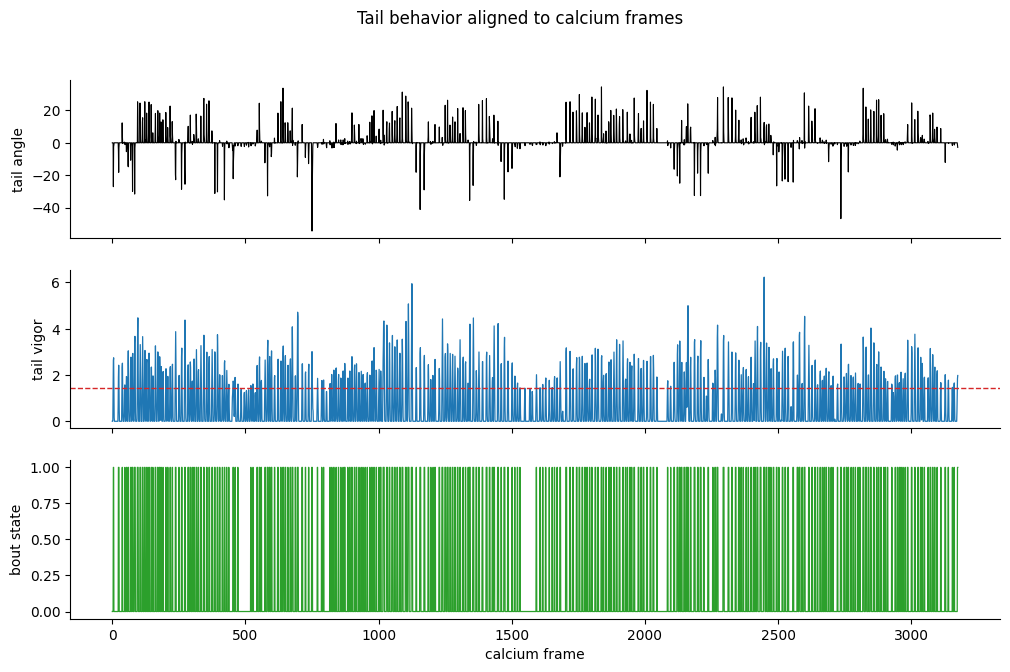

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
frames = np.arange(raw.shape[0])
axes[0].plot(frames, targets.angle, color="black", lw=0.8)
axes[0].set_ylabel("tail angle")
axes[1].plot(frames, targets.vigor, color="tab:blue", lw=0.9)
axes[1].axhline(targets.bout_threshold, color="tab:red", ls="--", lw=1)
axes[1].set_ylabel("tail vigor")
axes[2].plot(frames, targets.bout_state, color="tab:green", lw=0.9)
axes[2].set_ylabel("bout state")
axes[2].set_xlabel("calcium frame")
fig.suptitle("Tail behavior aligned to calcium frames");

## Paper-ready trace and behavior evidence

This panel can be generated before running the decoding experiment. It selects a representative neuron by a stated rule and aligns raw/denoised traces to the behavior window with the strongest bout structure.

In [ ]:
trace_evidence_fig, trace_evidence_axes = plot_behavior_trace_evidence(
    variants,
    targets,
    window_size=600,
)

## Run decoding experiments

In [9]:
common_kwargs = dict(
    variants=variants,
    lags=LAGS,
    target_shift=TARGET_SHIFT,
    n_splits=N_SPLITS,
    gap=GAP,
    ridge_alpha=RIDGE_ALPHA,
    include_transfer=True,
    include_null=True,
)

vigor_result = run_decoding_experiment(
    target=targets.vigor,
    target_name="tail_vigor",
    task="regression",
    **common_kwargs,
)

bout_result = run_decoding_experiment(
    target=targets.bout_state,
    target_name="bout_state",
    task="classification",
    **common_kwargs,
)

metrics = pd.concat([vigor_result.metrics, bout_result.metrics], ignore_index=True)
summary = pd.concat([vigor_result.summary, bout_result.summary], ignore_index=True)
summary.head()

,target,task,comparison,train_version,test_version,r2_mean,r2_std,pearson_mean,pearson_std,spearman_mean,...,rmse_mean,rmse_std,nrmse_mean,nrmse_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,roc_auc_mean,roc_auc_std
0,tail_vigor,regression,null_within,cleanedNew_0,cleanedNew_0,-0.506099,0.115383,-0.001464,0.012386,-0.008991,...,1.269910,0.094574,1.226513,0.046958,NaN,NaN,NaN,NaN,NaN,NaN
1,tail_vigor,regression,null_within,cleanedNew_1,cleanedNew_1,-0.083248,0.070168,-0.011237,0.032223,-0.009450,...,1.079143,0.105433,1.040370,0.033137,NaN,NaN,NaN,NaN,NaN,NaN
2,tail_vigor,regression,null_within,cleanedNew_2,cleanedNew_2,-0.072305,0.060351,-0.023062,0.060970,0.001235,...,1.072130,0.078431,1.035194,0.029104,NaN,NaN,NaN,NaN,NaN,NaN
3,tail_vigor,regression,null_within,cleanedNew_3,cleanedNew_3,-0.021373,0.032272,0.002939,0.025473,-0.011491,...,1.047736,0.091628,1.010531,0.015810,NaN,NaN,NaN,NaN,NaN,NaN
4,tail_vigor,regression,null_within,cleanedNew_4,cleanedNew_4,-0.025262,0.031434,0.012152,0.044640,0.002078,...,1.049213,0.083002,1.012459,0.015400,NaN,NaN,NaN,NaN,NaN,NaN


## Paper-ready decoding and preservation summary

Run this after the decoding experiment. It shows fold-level within-decoding, raw-to-denoised transfer, and the Behavioral Preservation Index used to rank methods.

In [ ]:
preservation_fig, preservation_axes, behavior_scorecard = plot_behavior_preservation_summary(
    metrics,
    summary,
    variants=variants,
)
behavior_scorecard

## Supplementary prediction traces for one fold

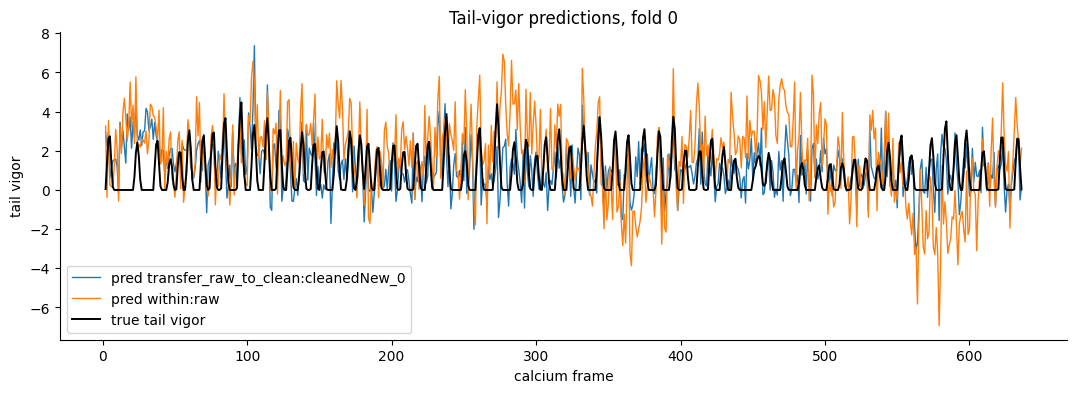

In [12]:
predictions = pd.concat([vigor_result.predictions, bout_result.predictions], ignore_index=True)
example_version = variants[1].name if len(variants) > 1 else "raw"
fold = 0
plot_df = predictions.query(
    "target == 'tail_vigor' and fold == @fold and "
    "((comparison == 'within' and test_version == 'raw') or "
    "(comparison == 'transfer_raw_to_clean' and test_version == @example_version))"
).copy()

fig, ax = plt.subplots(figsize=(13, 4))
for label, group in plot_df.groupby(["comparison", "test_version"]):
    ax.plot(group["time_index"], group["y_pred"], lw=1, label=f"pred {label[0]}:{label[1]}")
truth = plot_df.drop_duplicates("time_index").sort_values("time_index")
ax.plot(truth["time_index"], truth["y_true"], color="black", lw=1.4, label="true tail vigor")
ax.set_title(f"Tail-vigor predictions, fold {fold}")
ax.set_xlabel("calcium frame")
ax.set_ylabel("tail vigor")
ax.legend();

## Save outputs

In [ ]:
save_result(vigor_result, OUTPUT_DIR, "tail_vigor")
save_result(bout_result, OUTPUT_DIR, "bout_state")
metrics.to_csv(OUTPUT_DIR / "all_fold_metrics.csv", index=False)
summary.to_csv(OUTPUT_DIR / "all_summary.csv", index=False)
predictions.to_csv(OUTPUT_DIR / "all_predictions.csv", index=False)

if "behavior_scorecard" in globals():
    behavior_scorecard.to_csv(OUTPUT_DIR / "behavior_preservation_scorecard.csv", index=False)
if "trace_evidence_fig" in globals():
    trace_evidence_fig.savefig(OUTPUT_DIR / "paper_trace_behavior_evidence.png", dpi=300, bbox_inches="tight")
if "preservation_fig" in globals():
    preservation_fig.savefig(OUTPUT_DIR / "paper_behavior_preservation_summary.png", dpi=300, bbox_inches="tight")

OUTPUT_DIR